# Download Audio MNIST Dataset

Downloads the [Audio MNIST](https://huggingface.co/datasets/gilkeyio/AudioMNIST) dataset from Hugging Face and saves metadata to `data/processed/`.

In [54]:
from pathlib import Path
from datasets import load_dataset, Audio
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT_DIR = Path("..").resolve()
DATA_DIR = PROJECT_DIR / "data" / "processed"
DATA_DIR.mkdir(parents=True, exist_ok=True)

In [55]:
ds = load_dataset("gilkeyio/AudioMNIST")
ds = ds.cast_column("audio", Audio(decode=False))

print(f"Train: {len(ds['train'])} samples")
print(f"Test:  {len(ds['test'])} samples")
print(f"Columns: {ds['train'].column_names}")

Train: 24000 samples
Test:  6000 samples
Columns: ['speaker_id', 'audio', 'digit', 'gender', 'accent', 'age', 'native_speaker', 'origin']


In [56]:
records = [{
    "digit": s["digit"],
    "speaker_id": s["speaker_id"],
    "gender": "male" if s["gender"] == 0 else "female",
    "accent": s["accent"],
    "age": s["age"],
    "origin": s["origin"],
    "split": split_name,
} for split_name, split in ds.items() for s in split]

df = pd.DataFrame(records)
df.to_csv(DATA_DIR / "audio_mnist_metadata.csv", index=False)
print(f"Saved: {DATA_DIR / 'audio_mnist_metadata.csv'}")
print(f"Total: {len(df)} records")
df.head()

Saved: /home/amets/Documents/MASTER/SDOML/project/SDOML-project1/data/processed/audio_mnist_metadata.csv
Total: 30000 records


,digit,speaker_id,gender,accent,age,origin,split
0,7,59,female,German,31.0,"Europe, Germany, Berlin",train
1,7,59,female,German,31.0,"Europe, Germany, Berlin",train
2,2,59,female,German,31.0,"Europe, Germany, Berlin",train
3,3,59,female,German,31.0,"Europe, Germany, Berlin",train
4,9,59,female,German,31.0,"Europe, Germany, Berlin",train


### AUDIO MNIST ANALYSIS
Plot the class balance relation, metadata information of the speakers and train/validation split

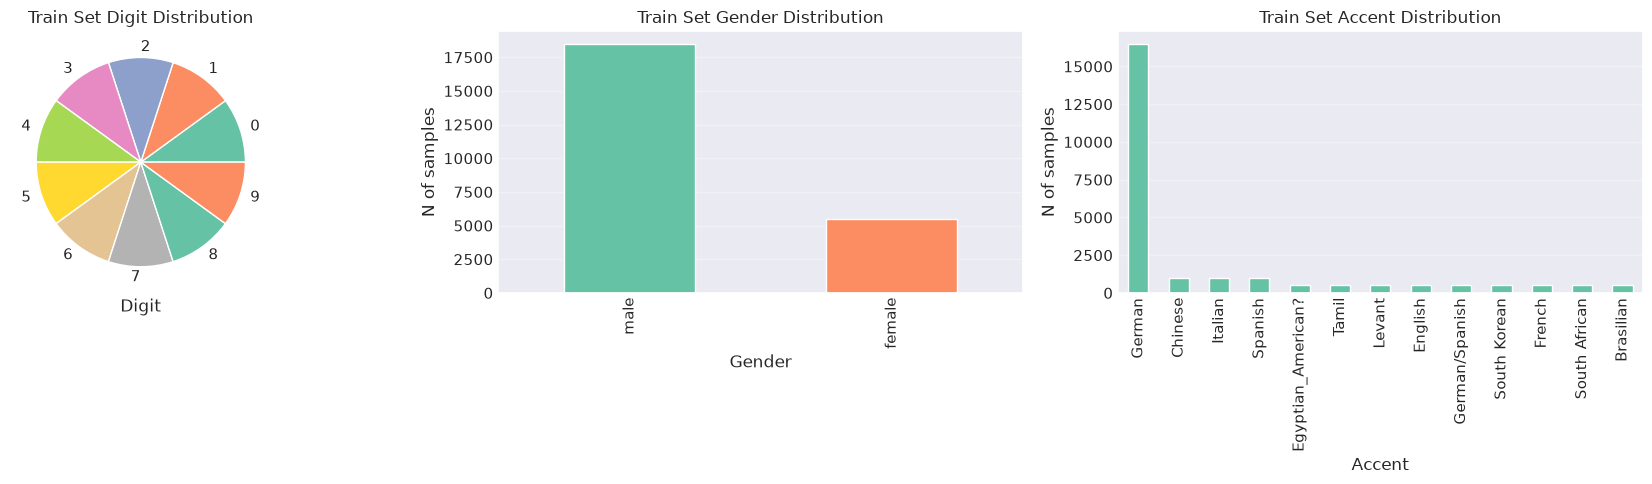

In [57]:
palette = sns.color_palette("Set2", n_colors=10)
train_df = df[df["split"] == "train"]
valid_df = df[df["split"] == "test"]

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Train Digit distribution
digit_counts = train_df["digit"].value_counts().sort_index()
digit_counts.plot.pie(ax=axs[0], colors=palette[:len(digit_counts)])
axs[0].set_title("Train Set Digit Distribution")
axs[0].set_xlabel("Digit")

# Train Gender distribution
train_df["gender"].value_counts().plot.bar(ax=axs[1], color=palette[:2])
axs[1].set_title("Train Set Gender Distribution")
axs[1].set_xlabel("Gender")
axs[1].set_ylabel("N of samples")
axs[1].grid(axis="y", alpha=0.3)

# Train Accent distribution
train_df["accent"].value_counts().plot.bar(ax=axs[2], color=palette[:1])
axs[2].set_title("Train Set Accent Distribution")
axs[2].set_xlabel("Accent")
axs[2].set_ylabel("N of samples")
axs[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

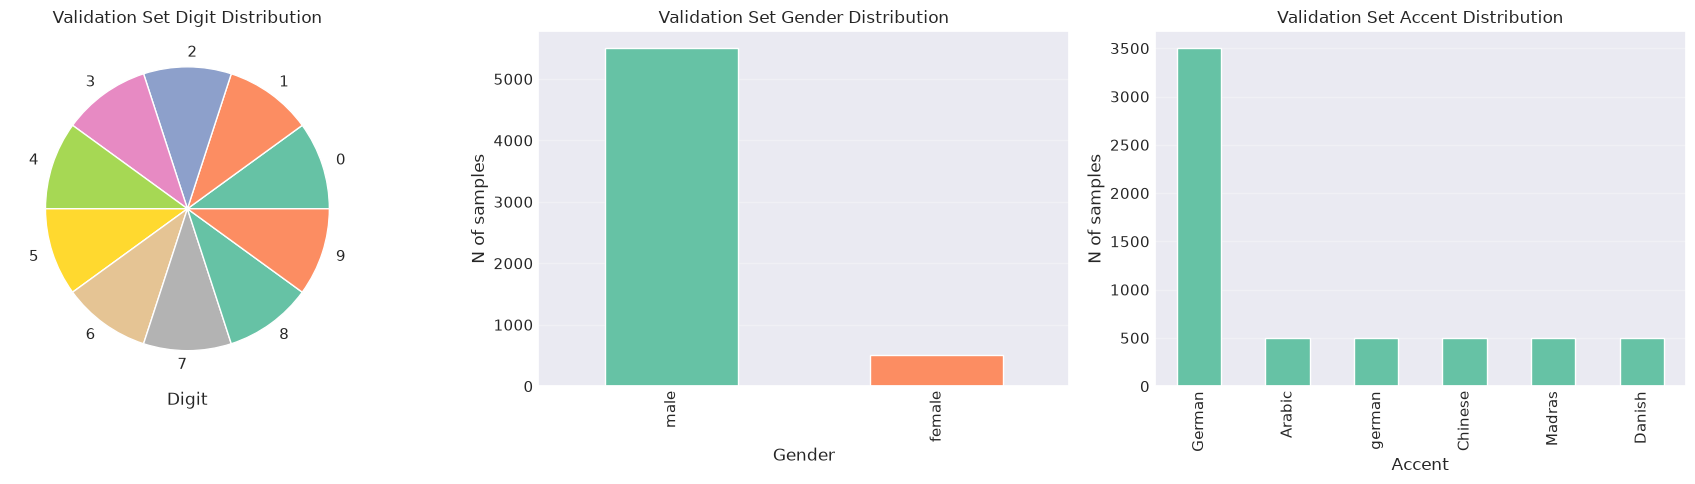

In [58]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Validation Digit distribution
digit_counts = valid_df["digit"].value_counts().sort_index()
digit_counts.plot.pie(ax=axs[0], colors=palette[:len(digit_counts)])
axs[0].set_title("Validation Set Digit Distribution")
axs[0].set_xlabel("Digit")

# Validation Gender distribution
valid_df["gender"].value_counts().plot.bar(ax=axs[1], color=palette[:2])
axs[1].set_title("Validation Set Gender Distribution")
axs[1].set_xlabel("Gender")
axs[1].set_ylabel("N of samples")
axs[1].grid(axis="y", alpha=0.3)

# Validation Accent distribution
valid_df["accent"].value_counts().plot.bar(ax=axs[2], color=palette[:1])
axs[2].set_title("Validation Set Accent Distribution")
axs[2].set_xlabel("Accent")
axs[2].set_ylabel("N of samples")
axs[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()